In [1]:
# 標準函式庫
import sys
import os
import warnings
import cv2


# 第三方函式庫 (科學計算/優化)
import emcee
import numpy as np
import scipy.constants as spc
from scipy.interpolate import interp1d
from scipy.optimize import fsolve # 假設你需要 fsolve

# 天文學/數據處理函式庫
from astropy import units as u
from astropy.io import fits 
from astropy.wcs import WCS
from spectral_cube import SpectralCube

# 繪圖函式庫
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import corner
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 專案本地模組
import PSSpy as pss

In [2]:
Local_Standard_Velocity = 5.86 #km/s (Gupta_2024)
pa_deg = 170 + 90
pa_rad = pa_deg * np.pi / 180

In [3]:
ra_start = '19:01:06.961'
ra_end = '19:01:10.248'
dec_deg = 36 + 57/60 + 20/3600  # +31.21.38.180 => 31.3606 度
distance_pc = 160
n_pixels = 789

radius_in_au, radius_out_au = 1e2, 3e3

arcsec_range, AU_per_pixel = pss.calc_ra_arcsec(ra_start, ra_end, dec_deg, distance_pc, n_pixels)

print(f"RA arcsec range (rounded): {arcsec_range} arcsec")
print(f"AU per pixel: {AU_per_pixel:.2f} AU/pixel")

RA arcsec range (rounded): 39 arcsec
AU per pixel: 7.91 AU/pixel


In [4]:

cube = SpectralCube.read('S_CrA_13CO_spw25_tav_jupyter_shifted.fits')
header = fits.getheader('S_CrA_13CO_spw25_tav_jupyter_shifted.fits')
w = WCS(header).sub(['longitude', 'latitude'])

im_center = int(header['CRPIX2']), int(header['CRPIX1'])  # (z, x)
v0 = header['CRVAL3']          # reference velocity
dx = abs(header['CDELT1'])      # arcsec per pixel
dz = abs(header['CDELT2'])      # arcsec per pixel
dv = abs(header['CDELT3'])      # km/s per channel
v_lastch_vel = 14.8636
v_lastch_num = 150

# Subcube and moment calculation
velocity_range = [2.4926, 14.8636] * u.km / u.s  # Adjusted velocity range
subcube = cube.spectral_slab(velocity_range[0], velocity_range[1])
moment0 = subcube.moment(order=0).value
moment1 = subcube.moment(order=1).value
rms_channel = 0.026211100061251217
rms_mom0 = 5.134089023394e-2
cube_shape = subcube.shape  # (n_channels, n_z, n_x)

# mom0_3rms = np.ma.masked_where(moment0 < 3.5*rms_channel, moment0)
# mom1_3rms = np.ma.masked_where(moment0 < 3.5*rms_channel, moment1)

/opt/anaconda3/lib/python3.11/site-packages/spectral_cube/_moments.py:168: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [5]:
cube_shape

(150, 778, 789)

In [6]:
im_center

(396, 396)

In [7]:
hdu_mom0 = fits.PrimaryHDU(data=moment0, header=header)
hdu_mom0.writeto('S_CrA_13CO_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=moment1.data, header=header)
hdu_mom1.header['BUNIT'] = 'km/s'
hdu_mom1.writeto('S_CrA_13CO_mom1.fits', overwrite=True)

In [8]:
find_streamcom = np.array([[396, 396], [371, 355], [340, 355], [309, 369], [279, 389], [257, 463]]) - (im_center[0], im_center[1])

In [9]:
find_r, find_theta = pss.spherical_coords(find_streamcom[:, 0], find_streamcom[:, 1])
find_streaml = interp1d(find_r, find_theta)

In [10]:
center1 = (388, 393)  # (y, x)
center2 = (369, 382)  # (y, x)

new_center = int((center1[0] + center2[0]) / 2), int((center1[1] + center2[1]) / 2) # (y, x)

ny, nx = moment0.shape
radius = 35

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), new_center, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], subcube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = subcube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

In [11]:
# cube_data = cube.filled_data[:].value  # shape = (z, y, x)
maskcent_cube_data = masked_center_cube.filled_data[:].value  # shape = (z, y, x)

init_points = [(35, new_center[0], new_center[1]), (35, 355, 371), (35, 355, 340), (35, 369, 309), (35, 389, 279), (35, 463, 257)]  # (z, y, x) coordinates of initial points
# stream_mask = pss.grow_region(cube_data, init_points, rms_channel, sigma_thresh=3.5, max_iter=1000)
maskcent_stream_mask = pss.grow_region(maskcent_cube_data, init_points, rms_channel, sigma_thresh=3.5, max_iter=1000)

In [12]:
masked_cube = masked_center_cube.with_mask(maskcent_stream_mask)

In [13]:
radius = 11
mask_pos_1 = [320, 412] # (y, x) - (18(ty), 9(tx))

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos_1, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], subcube.shape[0], axis=0)

# 套用到 cube
masked_cube_1 = masked_cube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

In [14]:
radius = 30
mask_pos_2 = [335, 438] # (y, x) - (18(ty), 9(tx))

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos_2, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], subcube.shape[0], axis=0)

# 套用到 cube
masked_cube_2 = masked_cube_1.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

In [15]:
# masked_cube_ori = cube.with_mask(stream_mask)
# masked_cube = masked_center_cube.with_mask(maskcent_stream_mask)
new_cube_data = masked_cube_2.with_fill_value(np.nan)
new_cube_data = new_cube_data.filled_data[:].value
# masked_cube = masked_cube.with_fill_value(0)

str_moment0 = masked_cube_2.moment(order=0).value
str_moment1 = masked_cube_2.moment(order=1).value
# str_moment0_ori = masked_cube_ori.moment(order=0).value
# str_moment1_ori = masked_cube_ori.moment(order=1).value

/opt/anaconda3/lib/python3.11/site-packages/spectral_cube/_moments.py:168: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [16]:
ty, tx = (im_center[0] - new_center[0], im_center[1] - new_center[1])

# Create the 2x3 translation matrix
# M = [[1, 0, tx],
#      [0, 1, ty]]
M = np.float32([[1, 0, tx], [0, 1, ty]])

# Get the image dimensions
rows, cols= str_moment0.shape

# Apply the affine transformation
shifted_str_mom0 = np.ma.masked_invalid(cv2.warpAffine(str_moment0, M, (cols, rows), borderValue=np.nan)).data
shifted_str_mom1 = np.ma.masked_invalid(cv2.warpAffine(str_moment1, M, (cols, rows), borderValue=np.nan)).data

# shifted_str_mom0_ori = np.ma.masked_invalid(cv2.warpAffine(str_moment0_ori, M, (cols, rows), borderValue=np.nan))
# shifted_str_mom1_ori = np.ma.masked_invalid(cv2.warpAffine(str_moment1_ori, M, (cols, rows), borderValue=np.nan))

In [ ]:
# 獲取平移後的空間維度 (cols=X, rows=Z)
nv, rows, cols = cube_shape

# 初始化一個用於存放平移後數據立方體的陣列
shifted_cube_data = np.full(new_cube_data.shape, np.nan, dtype=new_cube_data.dtype)

# 對 V 軸（速度軸）進行迴圈
for v_slice in range(nv):
    # 提取當前的 2D 空間切片
    original_slice = new_cube_data[v_slice, :, :]
    
    # 應用 2D 仿射變換 (cv2.warpAffine)
    # 使用與 2D 矩陣相同的 M 和 (cols, rows) 尺寸
    shifted_slice = cv2.warpAffine(
        original_slice, 
        M, 
        (cols, rows),  # 圖像尺寸 (X, Z)
        borderValue=np.nan # 邊界填充 NaN
    )
    
    # 將平移後的切片放回新的立方體中
    shifted_cube_data[v_slice, :, :] = shifted_slice



In [18]:
hdu_mom0 = fits.PrimaryHDU(data=shifted_str_mom0, header=header)
hdu_mom0.writeto('S_CrA_13CO_streamer_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=shifted_str_mom1, header=header)
hdu_mom1.writeto('S_CrA_13CO_streamer_mom1.fits', overwrite=True)

In [19]:
# # 從 FITS 檔頭獲取必要的 WCS 資訊
# w = WCS(header).sub(['longitude', 'latitude'])
# # 獲取影像的像素維度
# nx = header['NAXIS1']
# ny = header['NAXIS2']

# # 取得影像四個角落的物理座標（以度為單位）
# bottom_left_world = w.pixel_to_world(0, 0)
# top_right_world = w.pixel_to_world(nx - 1, ny - 1)

# # 將度數轉換為相對角秒（以中心點為參考）
# # 這裡我們假設你的 FITS 檔頭已經將參考點 (CRVAL) 設定為影像中心
# # 並且你的座標是從影像中心開始計算的相對座標
# # 如果不是，你需要根據你的中心點重新計算
# ra_offset_arcsec = (bottom_left_world.ra.deg - header['CRVAL1']) * 3600. * np.cos(np.deg2rad(dec_deg))
# dec_offset_arcsec = (bottom_left_world.dec.deg - header['CRVAL2']) * 3600.

# # 設定 extent，確保它是從最小到最大
# xmin = min(ra_offset_arcsec, (top_right_world.ra.deg - header['CRVAL1']) * 3600.)
# xmax = max(ra_offset_arcsec, (top_right_world.ra.deg - header['CRVAL1']) * 3600.)

# ymin = min(dec_offset_arcsec, (top_right_world.dec.deg - header['CRVAL2']) * 3600.)
# ymax = max(dec_offset_arcsec, (top_right_world.dec.deg - header['CRVAL2']) * 3600.)

# extent = (xmax, xmin, ymin, ymax)

# # --- 接下來的繪圖程式碼保持不變 ---
# # 繪圖
# fig = plt.figure(figsize=(8.27, 8.27))
# ax  = fig.add_subplot(111)
# # color
# norm = PowerNorm(gamma=0.5, vmin=0, vmax=np.nanmax(str_moment0))
# imcolor = ax.imshow(str_moment0, origin='lower', cmap='inferno', extent=extent, norm=norm)
# # color bar
# divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='3%', pad='1%')
# cbar = fig.colorbar(imcolor, cax=cax)
# cbar.set_label('(Jy/beam km/s)',fontsize=20)
# ax.scatter(0, 0, c='w', s=100, marker='+')
# # range
# ax.set_xlim(12.5, -12.5)
# ax.set_ylim(-12.5, 12.5)

# # axis label
# ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
# ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
# ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
# plt.show()

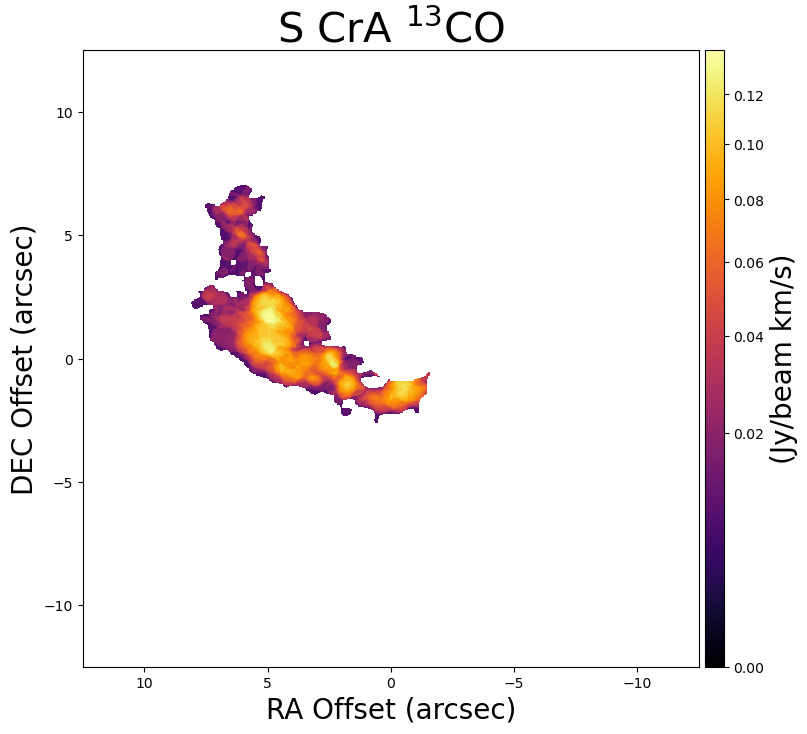

In [20]:
# ----------- input -----------
# parameters for plot
# moment I map in color
cmap       = 'inferno'  # color

# 獲取新中心點的世界坐標 (R.A._ref, Dec._ref)
ref_world = w.pixel_to_world(new_center[1], new_center[0])
ra_ref_deg = ref_world.ra.deg
dec_ref_deg = ref_world.dec.deg

# 獲取影像的像素維度
nx = header['NAXIS1']
ny = header['NAXIS2']

# 定義四個角落的像素坐標 (X 軸)
# 使用 np.array 進行向量化
x_pixels = np.array([0, nx - 1, 0, nx - 1])
y_pixels = np.array([0, 0, ny - 1, ny - 1])

# 透過 WCS 一次性轉換所有角落的坐標 (這是最關鍵的一步)
corner_worlds = w.pixel_to_world(x_pixels, y_pixels)

# 提取 R.A. 和 Dec. 的度數陣列
corner_ra_deg = corner_worlds.ra.deg
corner_dec_deg = corner_worlds.dec.deg

# 計算 R.A. 偏移 (度 -> 角秒)
ra_offset_arcsec = (corner_ra_deg - ra_ref_deg) * 3600. * np.cos(np.deg2rad(dec_deg))

# 計算 Dec 偏移 (度 -> 角秒)
dec_offset_arcsec = (corner_dec_deg - dec_ref_deg) * 3600.

# extent 格式為 (xmin, xmax, ymin, ymax)
# x 軸 (R.A.)
xmin_arcsec = np.min(ra_offset_arcsec)
xmax_arcsec = np.max(ra_offset_arcsec)

# y 軸 (Dec)
ymin_arcsec = np.min(dec_offset_arcsec)
ymax_arcsec = np.max(dec_offset_arcsec)

# 最終的 extent
extent = (xmax_arcsec, xmin_arcsec, ymin_arcsec, ymax_arcsec)

# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0, vmax=np.nanmax(shifted_str_mom0))  # Adjust gamma for better visibility

imcolor = ax.imshow(shifted_str_mom0, origin='lower',
    cmap=cmap, extent=extent, norm=norm)
plt.gca().set_aspect('equal') 

# color bar
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)

# save/show
folder_path = "image"
outname  = 'S CrA'  # outputname
# plt.savefig(os.path.join(folder_path, outname+'.png'), dpi=300, bbox_inches='tight')

plt.show()


In [32]:
# -----------------------------------------------------------------------
# 1. 建立 3D 座標網格
# -----------------------------------------------------------------------
# 這裡 v, z, x 是像素編號，與 cube_shape (v, z, x) 順序一致
v, z, x = np.indices(cube_shape)
# 相對於參考像素的座標
x_rel = x - im_center[1]
z_rel = z - im_center[0]

# 計算每個體素的球座標 (r, theta)
# r, theta 會是 3D 陣列，與 data_cube 相同維度
r, theta = pss.spherical_coords(x_rel, z_rel)

N_elements = 11
pars = np.linspace(40, 158, N_elements + 1)  # 徑向距離區間

x_means = np.zeros(N_elements)
z_means = np.zeros(N_elements)
v_means = np.zeros(N_elements)
xzstd = np.zeros(N_elements)

x_array_list = []
z_array_list = []
v_array_list = []
weights_list = []

# -----------------------------------------------------------------------
# 2. 找到每個徑向區間的 xz 平均座標
# -----------------------------------------------------------------------
for i in range(N_elements):
    r_streaml = (pars[i] + pars[i+1]) / 2
    theta0 = find_streaml(r_streaml)

    # 計算 3D 權重陣列
    weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r
    # 處理 r=0 的情況
    weight_theta[r==0] = 0
    
    # ⚠️ 
    # weight_theta[weight_theta < 0.99] = 0

    # 找出指定徑向範圍和有效數據的體素
    dinds = (r > pars[i]) & (r <= pars[i+1]) & (shifted_cube_data > 0)
    
    # 這裡的邏輯已經是正確的，但為了除錯，我們可以加入打印語句
    if np.sum(dinds) > 0:
        x_means[i] = np.average(x_rel[dinds], weights=shifted_cube_data[dinds] * weight_theta[dinds])
        z_means[i] = np.average(z_rel[dinds], weights=shifted_cube_data[dinds] * weight_theta[dinds])
        xzstd[i] = np.sqrt(np.average((x_rel[dinds] - x_means[i]) ** 2 + (z_rel[dinds] - z_means[i]) ** 2, weights=shifted_cube_data[dinds] * weight_theta[dinds]))
    else:
        x_means[i] = np.nan
        z_means[i] = np.nan
        xzstd[i] = np.nan

# -----------------------------------------------------------------------
# 3. 創建內插函數，用於計算高斯權重
# -----------------------------------------------------------------------
# 篩選掉 NaN 值，確保內插函數正確
valid_means_mask = np.isfinite(x_means)
if np.sum(valid_means_mask) < 2:
    print("數據太稀疏，無法建立內插函數，請檢查數據或參數")
    # 返回一個空的陣列或直接退出
    streamercom_v_pix = np.array([])
    streamercom_z_pix = np.array([])
    streamercom_x_pix = np.array([])
else:
    r_means, theta_means = pss.spherical_coords(x_means[valid_means_mask], z_means[valid_means_mask])
    theta_r = interp1d(r_means, theta_means, fill_value=(theta_means[0], theta_means[-1]), bounds_error=False)
    std_r = interp1d(r_means, xzstd[valid_means_mask], fill_value=(xzstd[0], xzstd[-1]), bounds_error=False)

# -----------------------------------------------------------------------
# 4. 計算 v, z, x 的加權平均
# -----------------------------------------------------------------------
for i in range(N_elements):
    r_ref = (pars[i] + pars[i+1]) / 2
    
    # 如果徑向區間無效，直接跳過
    if not np.isfinite(x_means[i]):
        x_means[i] = np.nan
        z_means[i] = np.nan
        v_means[i] = np.nan
        continue
        
    theta_ref = theta_r(r_ref)
    std_ref = std_r(r_ref) / r_ref
    
    # 計算 3D 高斯權重
    delta_theta = np.pi - np.abs(np.pi - np.abs(theta - theta_ref))
    weights = shifted_cube_data * pss.gaussian(delta_theta, 0, std_ref)
    
    dinds = (r > pars[i]) & (r <= pars[i+1]) & (shifted_cube_data > 0)

    # 存儲每次迴圈的值
    x_array_list.append(x_rel[dinds])
    z_array_list.append(z_rel[dinds])
    v_array_list.append(v[dinds])
    
    # 計算加權平均
    x_means[i] = np.average(x_rel[dinds], weights=weights[dinds])  
    z_means[i] = np.average(z_rel[dinds], weights=weights[dinds])
    v_means[i] = np.average(v[dinds], weights=weights[dinds])
    print(f"區間 {i}: x_means={x_means[i]}, z_means={z_means[i]}, v_means={v_means[i]}")


x_rotated = x_means * np.cos(pa_rad) + z_means * np.sin(pa_rad)
z_rotated = -x_means * np.sin(pa_rad) + z_means * np.cos(pa_rad)

# 轉換為物理單位
streamercom_x_AU = x_rotated * AU_per_pixel
streamercom_z_AU = z_rotated * AU_per_pixel
streamercom_v_km = v_lastch_vel + (v_means - v_lastch_num) * dv
streamercom_v_LS_km = streamercom_v_km - Local_Standard_Velocity
print(f"最終的像素座標 (x, z):")
print(f"X: {x_means}")
print(f"Z: {z_means}")
print(f"像素中心: {im_center}")

print(f"\n旋轉後的相對像素座標 (x, z):")
print(f"X: {x_rotated}")
print(f"Z: {z_rotated}")

print(f"從 3D 立方體中提取了 {np.sum(np.isfinite(x_means))} 個有效點。")

/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_94449/103209228.py:35: RuntimeWarning: invalid value encountered in divide
  weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r


區間 0: x_means=-3.7775813266239995, z_means=-44.018994733793704, v_means=41.22514151110865
區間 1: x_means=-38.84456271916692, z_means=-36.64680057941723, v_means=38.16405633022889
區間 2: x_means=-59.32427465618416, z_means=-25.800665095995306, v_means=36.20371685336871
區間 3: x_means=-74.15975919214085, z_means=-19.353796560260033, v_means=34.788362299023404
區間 4: x_means=-86.80380335379927, z_means=-11.023580507228987, v_means=36.087114745832054
區間 5: x_means=-92.34469276366767, z_means=-33.479675708384725, v_means=34.51546056376115
區間 6: x_means=-108.63050939205351, z_means=5.293515441952284, v_means=36.47618876906124
區間 7: x_means=-118.74022098792207, z_means=8.553944502100169, v_means=36.532198131946245
區間 8: x_means=-128.18421492834668, z_means=14.979394942550293, v_means=36.83550400120319
區間 9: x_means=-137.24747832568934, z_means=25.958451607215267, v_means=37.573838302007935
區間 10: x_means=-141.24028514353395, z_means=51.62197413004726, v_means=39.23651073500675
最終的像素座標 (x, z):
X: 

In [33]:
v_means

array([41.22514151, 38.16405633, 36.20371685, 34.7883623 , 36.08711475,
       34.51546056, 36.47618877, 36.53219813, 36.835504  , 37.5738383 ,
       39.23651074])

In [34]:
streamercom_v_LS_km

array([-0.0275997 , -0.281751  , -0.44451119, -0.56202318, -0.45419226,
       -0.58468126, -0.42188879, -0.41723853, -0.39205609, -0.33075475,
       -0.19270882])

In [685]:
# # -----------------------------------------------------------------------
# # 步驟 1: 建立 3D 座標網格與徑向區間
# # -----------------------------------------------------------------------
# v, z, x = np.indices(cube_shape)
# x_rel = x - im_center[1]
# z_rel = z - im_center[0]

# r, theta = pss.spherical_coords(x_rel, z_rel)

# N_elements = 11
# pars = np.linspace(50, 150, N_elements + 1)  # 徑向距離區間

# # 用於儲存質心點
# x_means = np.zeros(N_elements)
# z_means = np.zeros(N_elements)
# v_means = np.zeros(N_elements)
# xzstd = np.zeros(N_elements)

# x_array_list = []
# z_array_list = []
# v_array_list = []

# # -----------------------------------------------------------------------
# # 步驟 2: 找到每個徑向區間的初步 x, z, v 質心
# # -----------------------------------------------------------------------
# print("--- 正在尋找每個徑向區間的質心 ---")
# for i in range(N_elements):
#     # 找出指定徑向範圍和有效數據的體素
#     # ⚠️ 修正: 不使用 weight_theta，只用強度作為初步篩選權重
#     dinds = (r > pars[i]) & (r <= pars[i+1]) & (shifted_cube_data > 0)
    
#     if np.sum(dinds) > 0:
#         # 計算加權平均 (只用強度作為權重)
#         x_means[i] = np.average(x_rel[dinds], weights=shifted_cube_data[dinds])
#         z_means[i] = np.average(z_rel[dinds], weights=shifted_cube_data[dinds])
#         v_means[i] = np.average(v[dinds], weights=shifted_cube_data[dinds])
        
#         # 計算加權標準差
#         xzstd[i] = np.sqrt(np.average((x_rel[dinds] - x_means[i]) ** 2 + (z_rel[dinds] - z_means[i]) ** 2, weights=shifted_cube_data[dinds]))
#     else:
#         # 如果該區間沒有有效數據，賦予 NaN
#         x_means[i] = np.nan
#         z_means[i] = np.nan
#         v_means[i] = np.nan
#         xzstd[i] = np.nan

# print(f"找到 {np.sum(np.isfinite(x_means))} 個有效質心點。")


# # -----------------------------------------------------------------------
# # 步驟 3: 創建內插函數，並用高斯權重修正質心
# # -----------------------------------------------------------------------
# # 篩選掉 NaN 值，確保內插函數正確
# valid_means_mask = np.isfinite(x_means)
# if np.sum(valid_means_mask) < 2:
#     print("數據太稀疏，無法建立內插函數，請檢查數據或參數")
#     streamercom_v_pix = np.array([])
#     streamercom_z_pix = np.array([])
#     streamercom_x_pix = np.array([])
# else:
#     r_means, theta_means = pss.spherical_coords(x_means[valid_means_mask], z_means[valid_means_mask])
#     theta_r = interp1d(r_means, theta_means, fill_value=(theta_means[0], theta_means[-1]), bounds_error=False)
#     std_r = interp1d(r_means, xzstd[valid_means_mask], fill_value=(xzstd[0], xzstd[-1]), bounds_error=False)
    
#     # 創建新的、經過高斯加權的質心點
#     x_means_final = np.zeros(N_elements)
#     z_means_final = np.zeros(N_elements)
#     v_means_final = np.zeros(N_elements)
    
#     for i in range(N_elements):
#         r_ref = (pars[i] + pars[i+1]) / 2
        
#         # 如果初步質心是 NaN，則最終質心也是 NaN
#         if not np.isfinite(x_means[i]):
#             x_means_final[i] = np.nan
#             z_means_final[i] = np.nan
#             v_means_final[i] = np.nan
#             continue
        
#         theta_ref = theta_r(r_ref)
#         std_ref = std_r(r_ref) / r_ref
        
#         delta_theta = np.pi - np.abs(np.pi - np.abs(theta - theta_ref))
#         weights = shifted_cube_data * pss.gaussian(delta_theta, 0, std_ref)
#         dinds = (r > pars[i]) & (r <= pars[i+1]) & (shifted_cube_data > 0)
        
#         # 計算最終的加權平均
#         x_means_final[i] = np.average(x_rel[dinds], weights=weights[dinds])
#         z_means_final[i] = np.average(z_rel[dinds], weights=weights[dinds])
#         v_means_final[i] = np.average(v[dinds], weights=weights[dinds])
#         print(f"區間 {i}: x_means={x_means_final[i]}, z_means={z_means_final[i]}, v_means={v_means_final[i]}")

#     streamercom_v_pix = np.array(v_means_final) 
#     streamercom_z_pix = np.array(z_means_final)
#     streamercom_x_pix = np.array(x_means_final)

# # ... (後續的座標轉換和繪圖程式碼保持不變)

In [ ]:
# vv, z_idx, x_idx = np.indices(cube_shape)

# # 2. 直接建立你最終需要的 3D 座標網格
# #    (xx, zz, vv 現在已經是最終成品了！)
# xx = x_idx - im_center[1]
# zz = z_idx - im_center[0]
# # --- 座標與網格設定 ---
# # --- CHANGED: 建立 3D 網格
# r, theta = pss.spherical_coords(xx, zz)

# # --- 參數與初始化 ---
# N_elements = 11
# pars = np.linspace(40, 190, N_elements + 1)  # 徑向距離區間
# xmeans = np.zeros(N_elements)
# zmeans = np.zeros(N_elements)
# vmeans = np.zeros(N_elements)  # +++ ADDED: 用於儲存第一次迭代的速度平均值
# xzstd = np.zeros(N_elements)

# x_means = np.zeros(N_elements)
# z_means = np.zeros(N_elements)
# v_means = np.zeros(N_elements)

# # --- 第一次迭代：初步尋找結構中心 ---
# print("--- 正在尋找每個徑向區間的質心 (僅使用正權重) ---")
# for i in range(N_elements):
#     dinds = (r > pars[i]) & (r <= pars[i+1]) & (shifted_cube_data > 0)
#     if not np.any(dinds): continue

#     # 提取該區域的體素 (voxel) 和座標
#     region_data = shifted_cube_data[dinds]
#     region_xx = xx[dinds]
#     region_zz = zz[dinds]
#     region_vv = vv[dinds]

#     # 關鍵改動：只篩選出訊號為正的點來計算加權平均
#     positive_mask = region_data > 0
#     if not np.any(positive_mask):
#         # 如果這個環帶內沒有任何正訊號，就填入 NaN
#         xmeans[i], zmeans[i], vmeans[i], xzstd[i] = np.nan, np.nan, np.nan, np.nan
#         continue
    
#     weights = region_data[positive_mask]
    
#     xmeans[i] = np.average(region_xx[positive_mask], weights=weights)
#     zmeans[i] = np.average(region_zz[positive_mask], weights=weights)
#     vmeans[i] = np.average(region_vv[positive_mask], weights=weights)
    
#     xzstd[i] = np.sqrt(np.average((region_xx[positive_mask] - xmeans[i])**2 + (region_zz[positive_mask] - zmeans[i])**2, weights=weights))

# print(f"找到 {np.sum(np.isfinite(xmeans))} 個有效質心點。")

# # --- 內插：建立模型 ---
# r_means_pass1, theta_means_pass1 = pss.spherical_coords(xmeans, zmeans)

# # 篩選掉 NaN 值以避免內插錯誤
# valid_interp = np.isfinite(r_means_pass1)

# theta_r = interp1d(r_means_pass1[valid_interp], theta_means_pass1[valid_interp], fill_value="extrapolate", bounds_error=False)
# std_r = interp1d(r_means_pass1[valid_interp], xzstd[valid_interp], fill_value="extrapolate", bounds_error=False)
# v_r = interp1d(r_means_pass1[valid_interp], vmeans[valid_interp], fill_value="extrapolate", bounds_error=False)  # +++ ADDED: 建立速度的內插模型

# # --- 第二次迭代：使用時空遮罩精確尋找 ---
# x_array_list = []
# z_array_list = []
# v_array_list = [] # +++ ADDED
# weights_list = []

# for i in range(N_elements):
#     # 預測此環帶的中心參數
#     r_ref = (pars[i] + pars[i+1]) / 2
#     theta_ref = theta_r(r_ref)
#     std_ref = std_r(r_ref) / r_ref  # 角標準差
#     v_ref = v_r(r_ref)             # +++ ADDED: 預測的速度中心
#     v_std_ref = 5.0                # +++ ADDED: 假設一個速度寬度(km/s)，這個值需要根據數據調整

#     # --- CHANGED: 核心修改，建立 3D 權重
#     delta_theta = np.pi - np.abs(np.pi - np.abs(theta - theta_ref))
#     # 權重 = 原始強度 * 空間高斯(角度) * 速度高斯
#     weights = shifted_cube_data * pss.gaussian(delta_theta, 0, std_ref) * pss.gaussian(vv, v_ref, v_std_ref)
    
#     dinds = (r > pars[i]) & (r <= pars[i+1]) & (shifted_cube_data > 0)
#     if not np.any(dinds): continue
        
#     # 存儲每次迴圈的值
#     x_array_list.append(xx[dinds])
#     z_array_list.append(zz[dinds])
#     v_array_list.append(vv[dinds]) # +++ ADDED: 存儲體素的速度
#     weights_list.append(weights[dinds] / np.max(weights[dinds]))
    
#     # --- CHANGED: 使用新的 3D 權重計算平均值
#     x_means[i] = np.average(xx[dinds], weights=weights[dinds])
#     z_means[i] = np.average(zz[dinds], weights=weights[dinds])
#     v_means[i] = np.average(vv[dinds], weights=weights[dinds]) # --- CHANGED
#     print(f"區間 {i}: x_means={x_means[i]}, z_means={z_means[i]}, v_means={v_means[i]}")

# # --- 整理最終結果 ---
# r_means, theta_means = pss.spherical_coords(x_means, z_means)

# x_array = np.array(x_array_list, dtype=object)
# z_array = np.array(z_array_list, dtype=object)
# v_array = np.array(v_array_list, dtype=object) # +++ ADDED
# weights_array = np.array(weights_list, dtype=object)

--- 正在尋找每個徑向區間的質心 (僅使用正權重) ---
找到 11 個有效質心點。
區間 0: x_means=-8.053280744887871, z_means=-44.443967083243116, v_means=40.68560164401998
區間 1: x_means=-48.66024601145131, z_means=-32.09430282677595, v_means=37.226372306634524
區間 2: x_means=-70.20823340294356, z_means=-18.814669122297975, v_means=35.36308946178862
區間 3: x_means=-86.53290243692159, z_means=-11.303731930519461, v_means=36.04947598715163
區間 4: x_means=-95.21758377394416, z_means=-30.718555436414547, v_means=34.76796136155412
區間 5: x_means=-113.54939210281269, z_means=7.463761298642571, v_means=36.43425860800458
區間 6: x_means=-126.14662736097816, z_means=11.158022607713002, v_means=36.549300832066294
區間 7: x_means=-135.97101597076033, z_means=31.879725087190742, v_means=38.017928472658014
區間 8: x_means=-139.54031483419385, z_means=65.23039872825737, v_means=39.84104239668618
區間 9: x_means=-136.29667590624334, z_means=100.08377595680172, v_means=40.78361131457103
區間 10: x_means=-146.21559431124626, z_means=104.88526085195502, v

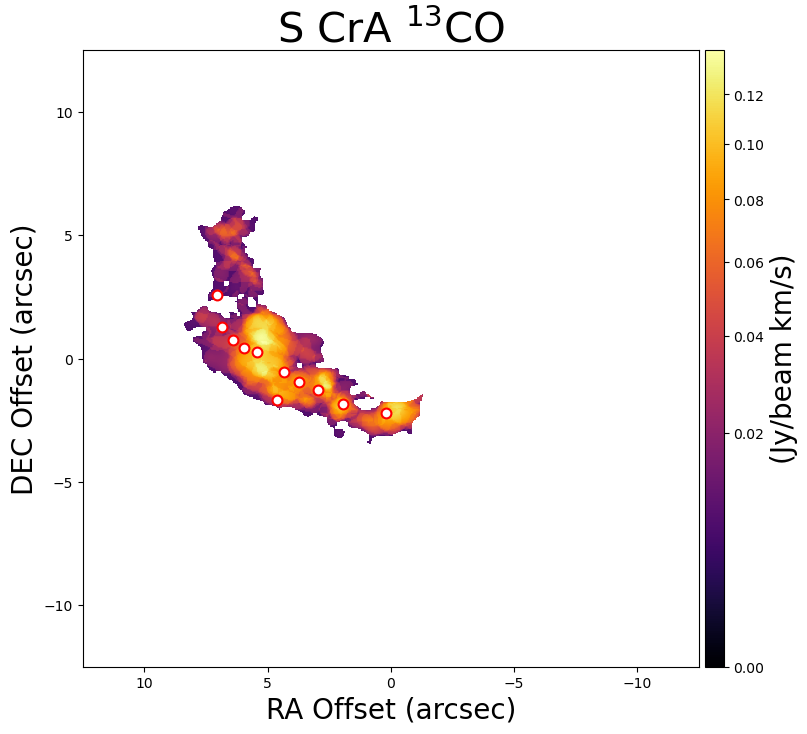

In [35]:
# ----------- input -----------
# parameters for plot
# moment I map in color
cmap       = 'inferno'  # color

# 獲取新中心點的世界坐標 (R.A._ref, Dec._ref)
ref_world = w.pixel_to_world(new_center[1], new_center[0])
ra_ref_deg = ref_world.ra.deg
dec_ref_deg = ref_world.dec.deg

streamercom_world = w.pixel_to_world(x_means + new_center[1], z_means + new_center[0])

streamercom_ra_arcsec = (streamercom_world.ra.deg - ra_ref_deg) * 3600. * np.cos(np.deg2rad(dec_ref_deg))
streamercom_dec_arcsec = (streamercom_world.dec.deg - dec_ref_deg) * 3600.

# --- 3. 計算 shifted_str_mom0 的正確 extent ---
# extent 必須描述 shifted_str_mom0 這個陣列的物理邊界
# 在這個陣列中，im_center 像素點對應的是天空中的 new_center 位置（即圖上的 0,0）
rows, cols = shifted_str_mom0.shape
dx_arcsec = abs(header['CDELT1']) * 3600.
dz_arcsec = abs(header['CDELT2']) * 3600.

# 計算陣列四個角落的像素，相對於 im_center 的偏移量，再轉換為角秒
# RA 偏移 (X 軸)
ra_min_offset = (0 - im_center[1]) * dx_arcsec
ra_max_offset = (cols - im_center[1]) * dx_arcsec
# DEC 偏移 (Z 軸/Y 軸)
dec_min_offset = (0 - im_center[0]) * dz_arcsec
dec_max_offset = (rows - im_center[0]) * dz_arcsec

# extent 格式為 (left, right, bottom, top)
# RA 軸是反的，所以 left 對應 max_offset, right 對應 min_offset
extent = [ra_max_offset, ra_min_offset, dec_min_offset, dec_max_offset]
# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0, vmax=np.nanmax(shifted_str_mom0))  # Adjust gamma for better visibility

imcolor = ax.imshow(shifted_str_mom0, origin='lower',
    cmap=cmap, extent=extent, norm=norm)
plt.gca().set_aspect('equal') 

ax.scatter(0, 0, c='w', s=100, marker='+')
ax.scatter(streamercom_ra_arcsec, streamercom_dec_arcsec,
           c='white', s=50, marker='o', edgecolors='red', linewidths=1.5,
           label='Streamer Centroids')# range
# color bar
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)

# save/show
folder_path = "image"
outname  = 'S CrA'  # outputname
# plt.savefig(os.path.join(folder_path, outname+'.png'), dpi=300, bbox_inches='tight')

plt.show()


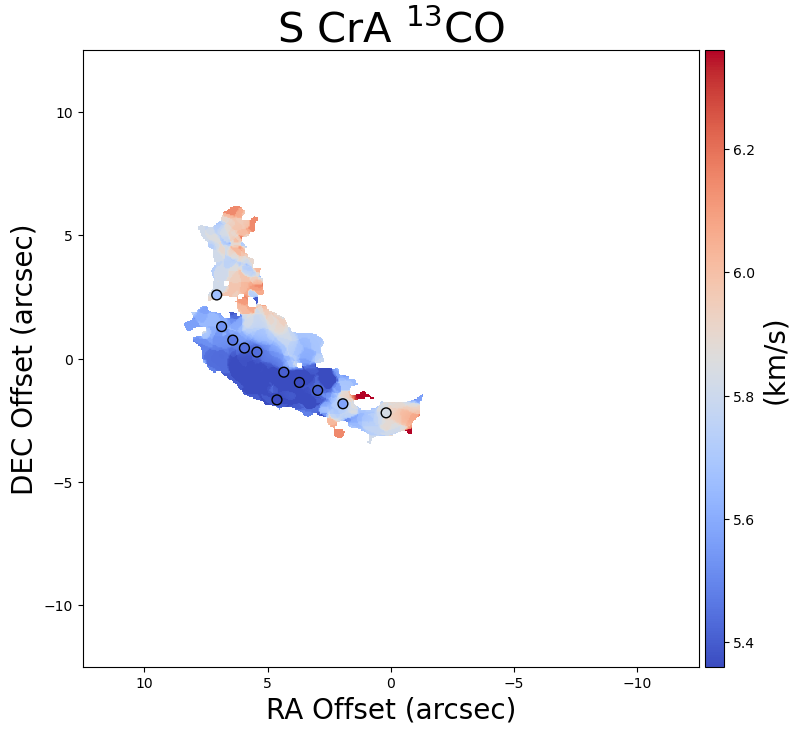

In [36]:
# 繪圖
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
cmap = 'coolwarm'
vmin, vmax = Local_Standard_Velocity - 0.5, Local_Standard_Velocity + 0.5   # color range
imcolor = ax.imshow(shifted_str_mom1, origin='lower', cmap=cmap, extent=extent, vmin=vmin, vmax=vmax)
# color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(km/s)',fontsize=20)
ax.scatter(0, 0, c='w', s=100, marker='+')
ax.scatter(streamercom_ra_arcsec, streamercom_dec_arcsec,
           c=streamercom_v_km, cmap=cmap, vmin=vmin, vmax=vmax,
           s=50, marker='o', edgecolors='black', linewidths=1,
           label='Streamer Centroids')# range


ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()